# Flattened color spaces and example outliers

**Purpose**: Produce plot from Figure 3B with a flattened color space and highlighting outlier images as examples.

### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import ttest_ind

# for visualizing outliers
import os
import json
import base64
from PIL import Image
from io import BytesIO
import cv2

# for converting cielab to LCh
from colormath.color_objects import LabColor, LCHabColor
from colormath.color_conversions import convert_color

# for the 3d histogram
from mpl_toolkits.mplot3d import Axes3D
from skimage.color import lab2rgb

### Read in data and reduce to one image per observation:

In [2]:
color_df = pd.read_csv('../datasets/geo_med.csv')

In [3]:
color_df_reduced = (
    color_df.groupby("gbifID", sort=False, group_keys=False)
    .apply(lambda x: x.sample(1,random_state=123))
    .reset_index(drop=True)
)
color_df_reduced

/var/folders/qh/c7rwx84921n2kznn09zb2pnh0000gn/T/ipykernel_6758/1712891894.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(1,random_state=123))


,image_idx,hex,rgb,hsl,lab,gbifID,identifier,latitude,longitude
0,0,#d4b4e2,"(212, 180, 226)","(0.782608695652174, 0.44230769230769224, 0.796...","(197, 148, 109)",923911394,https://inaturalist-open-data.s3.amazonaws.com...,48.826305,-102.092171
1,2,#cdb3cd,"(205, 179, 205)","(0.8333333333333334, 0.2063492063492065, 0.752...","(193, 142, 118)",923910407,https://inaturalist-open-data.s3.amazonaws.com...,43.613086,-73.057076
2,4,#bda5d7,"(189, 165, 215)","(0.7466666666666667, 0.3846153846153846, 0.745...","(182, 146, 106)",899970365,https://inaturalist-open-data.s3.amazonaws.com...,43.066871,-87.890565
3,7,#9984ae,"(153, 132, 174)","(0.75, 0.2058823529411765, 0.6000000000000001)","(149, 144, 109)",891778924,https://inaturalist-open-data.s3.amazonaws.com...,42.140556,-87.831643
4,9,#ba9fdd,"(186, 159, 221)","(0.739247311827957, 0.476923076923077, 0.74509...","(178, 150, 100)",891760719,https://inaturalist-open-data.s3.amazonaws.com...,38.679240,-97.990035
...,...,...,...,...,...,...,...,...,...
16582,41059,#a191c2,"(161, 145, 194)","(0.7210884353741497, 0.2865497076023391, 0.664...","(161, 144, 105)",1024218211,https://inaturalist-open-data.s3.amazonaws.com...,41.569419,-88.150552
16583,41060,#b77fb7,"(183, 127, 183)","(0.8333333333333334, 0.28, 0.607843137254902)","(154, 159, 107)",1024202810,https://inaturalist-open-data.s3.amazonaws.com...,45.057871,-87.168277
16584,41061,#af96cb,"(175, 150, 203)","(0.7452830188679246, 0.3375796178343948, 0.692...","(168, 148, 104)",1024200169,https://inaturalist-open-data.s3.amazonaws.com...,42.921738,-88.026752
16585,41063,#c5b9b2,"(197, 185, 178)","(0.06140350877192979, 0.1407407407407409, 0.73...","(194, 131, 133)",1024198670,https://inaturalist-open-data.s3.amazonaws.com...,40.791723,-80.492498


### Add separate component rows

In [4]:
L = [(int(i.strip('()').split(', ')[0])) for i in color_df_reduced.lab]
L = (np.array(L) / 255.0) * 100.0  
color_df_reduced['L'] = L
a = [(int(i.strip('()').split(', ')[1])) for i in color_df_reduced.lab]
a = np.array(a) - 128.0  
color_df_reduced['a'] = a
b = [(int(i.strip('()').split(', ')[2])) for i in color_df_reduced.lab]
b = np.array(b) - 128.0
color_df_reduced['b'] = b

### All

In [5]:
lab_raw = color_df_reduced[["L", "a", "b"]].to_numpy().astype(float)

lab_true = lab_raw.copy()

lch_arr = np.empty_like(lab_true)
for i, (L_, a_, b_) in enumerate(lab_true):
    # had to think carefully here -- these look like the correct defaults
    # rather than d50 illuminant because of I used opencv at its default
    lab = LabColor(L_, a_, b_, observer='2', illuminant='d65') 
    lch = convert_color(lab, LCHabColor)
    lch_arr[i] = lch.get_value_tuple()

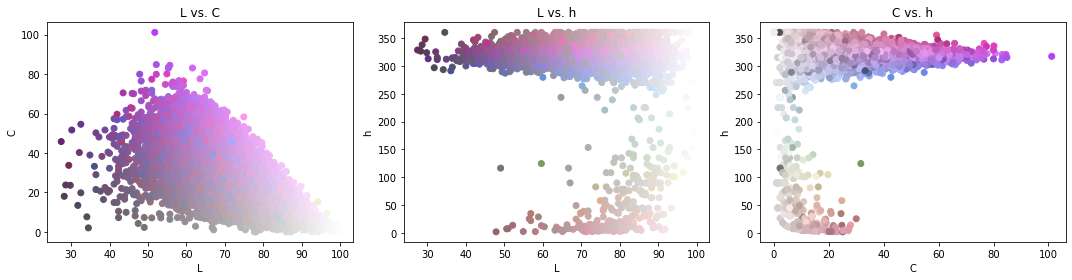

In [6]:
L, C, h = lch_arr.T

fig, axes = plt.subplots(1, 3, figsize=(15, 4), tight_layout=True)

axes[0].scatter(L, C, alpha=1,c=color_df_reduced.hex)
axes[0].set_xlabel('L'); axes[0].set_ylabel('C'); axes[0].set_title('L vs. C')

axes[1].scatter(L, h, alpha=1,c=color_df_reduced.hex)
axes[1].set_xlabel('L'); axes[1].set_ylabel('h'); axes[1].set_title('L vs. h')

axes[2].scatter(C, h, alpha=1,c=color_df_reduced.hex)
axes[2].set_xlabel('C'); axes[2].set_ylabel('h'); axes[2].set_title('C vs. h')

plt.savefig('../figures/figures_current/components/figure_3b.pdf',dpi=300)

plt.show()

# Looking at outliers

In [7]:
color_df_reduced[(h > 50) & (h < 250)]# & (C>20)]

,image_idx,hex,rgb,hsl,lab,gbifID,identifier,latitude,longitude,L,a,b
116,368,#c5c4c2,"(197, 196, 194)","(0.11111111111111165, 0.02521008403361359, 0.7...","(202, 128, 129)",5062742129,https://inaturalist-open-data.s3.amazonaws.com...,42.156086,-88.013619,79.215686,0.0,1.0
243,823,#dfdcb6,"(223, 220, 182)","(0.1544715447154472, 0.3904761904761906, 0.794...","(222, 123, 147)",5007817820,https://inaturalist-open-data.s3.amazonaws.com...,34.662700,-92.936789,87.058824,-5.0,19.0
272,958,#cfcdc7,"(207, 205, 199)","(0.12500000000000014, 0.07692307692307694, 0.7...","(210, 128, 131)",5007237520,https://inaturalist-open-data.s3.amazonaws.com...,42.959045,-89.765107,82.352941,0.0,3.0
298,1056,#f6f6e3,"(246, 246, 227)","(0.16666666666666666, 0.5135135135135143, 0.92...","(246, 125, 137)",5006900182,https://inaturalist-open-data.s3.amazonaws.com...,35.168695,-93.626055,96.470588,-3.0,9.0
324,1151,#c7cabf,"(199, 202, 191)","(0.21212121212121202, 0.09401709401709389, 0.7...","(206, 125, 133)",4993978296,https://inaturalist-open-data.s3.amazonaws.com...,35.700266,-82.379634,80.784314,-3.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
16139,40043,#e1ddd6,"(225, 221, 214)","(0.10606060606060623, 0.15492957746478864, 0.8...","(225, 128, 132)",1802625346,https://inaturalist-open-data.s3.amazonaws.com...,38.972437,-77.177821,88.235294,0.0,4.0
16498,40866,#c1d3d9,"(193, 211, 217)","(0.5416666666666666, 0.24000000000000005, 0.80...","(213, 123, 123)",1291090132,https://inaturalist-open-data.s3.amazonaws.com...,30.490785,-95.268910,83.529412,-5.0,-5.0
16550,41004,#c9d6d7,"(201, 214, 215)","(0.5119047619047619, 0.14893617021276603, 0.81...","(216, 124, 126)",1132416630,https://inaturalist-open-data.s3.amazonaws.com...,39.430161,-77.772789,84.705882,-4.0,-2.0
16564,41026,#cec6be,"(206, 198, 190)","(0.08333333333333333, 0.14035087719298248, 0.7...","(205, 129, 133)",1099970054,https://inaturalist-open-data.s3.amazonaws.com...,35.176589,-93.617656,80.392157,1.0,5.0


In [8]:
119 / len(color_df_reduced)

0.007174293121118948

## Isolate key outliers

#### high chroma, green

In [9]:
color_df_reduced[(h > 50) & (h < 250) & (C>30)]

,image_idx,hex,rgb,hsl,lab,gbifID,identifier,latitude,longitude,L,a,b
3384,9093,#809761,"(128, 151, 97)","(0.23765432098765435, 0.217741935483871, 0.486...","(152, 110, 154)",4875570513,https://inaturalist-open-data.s3.amazonaws.com...,34.753462,-93.4445,59.607843,-18.0,26.0


#### low chroma, 180-ish

In [10]:
color_df_reduced[(h > 170) & (h < 190) & (C>5)]

,image_idx,hex,rgb,hsl,lab,gbifID,identifier,latitude,longitude,L,a,b
12506,31606,#cfe8e4,"(207, 232, 228)","(0.47333333333333344, 0.3521126760563381, 0.86...","(230, 119, 127)",2988340521,https://inaturalist-open-data.s3.amazonaws.com...,34.6135,-93.511483,90.196078,-9.0,-1.0


#### high chroma, blue (260-ish)

In [11]:
color_df_reduced[(h > 250) & (h < 265) & (C>20)]

,image_idx,hex,rgb,hsl,lab,gbifID,identifier,latitude,longitude,L,a,b
15643,38896,#82b0e0,"(130, 176, 224)","(0.5851063829787234, 0.6025641025641025, 0.694...","(179, 125, 99)",1931488334,https://inaturalist-open-data.s3.amazonaws.com...,41.279793,-89.017563,70.196078,-3.0,-29.0


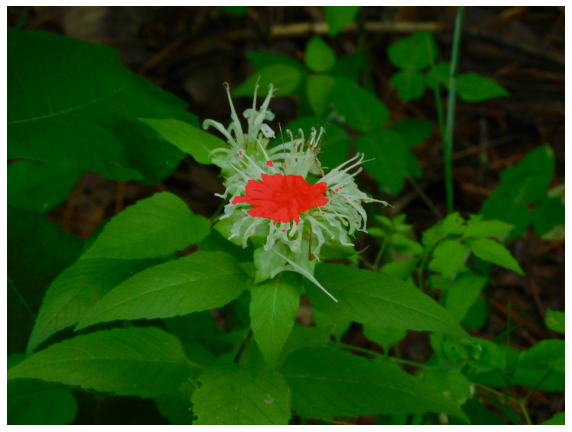

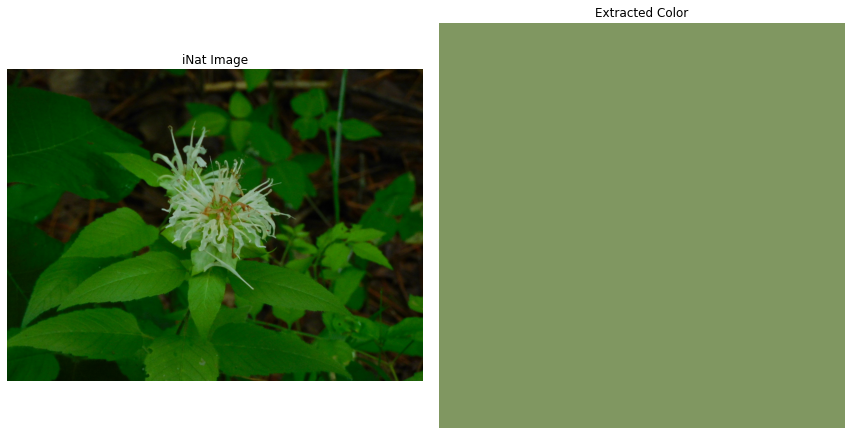

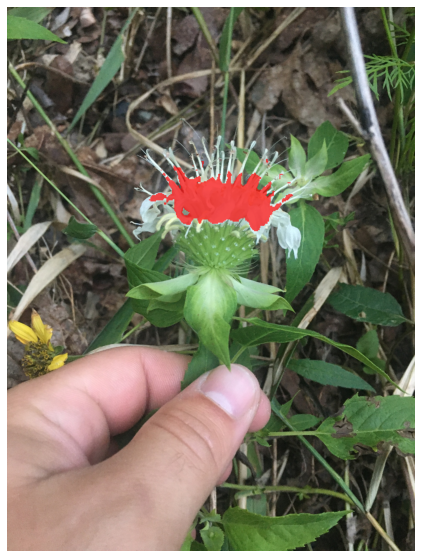

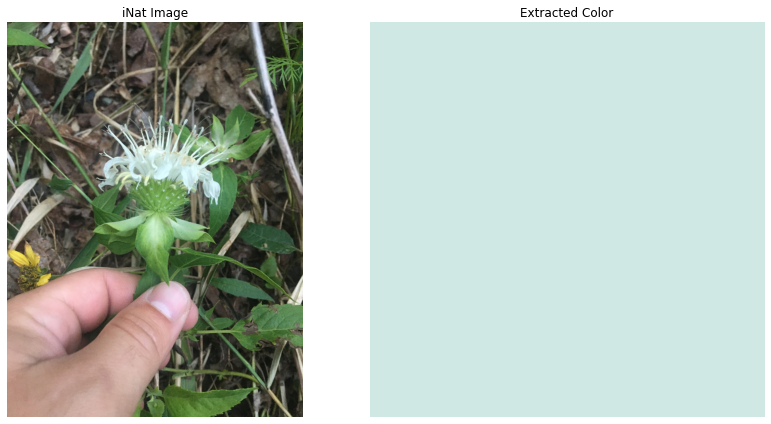

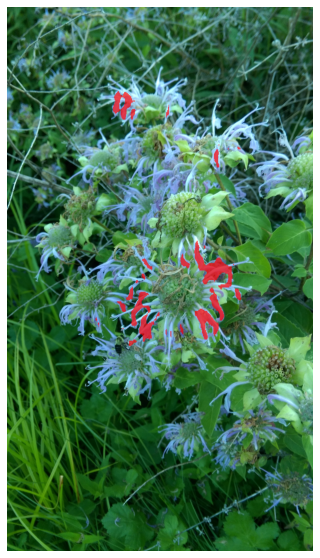

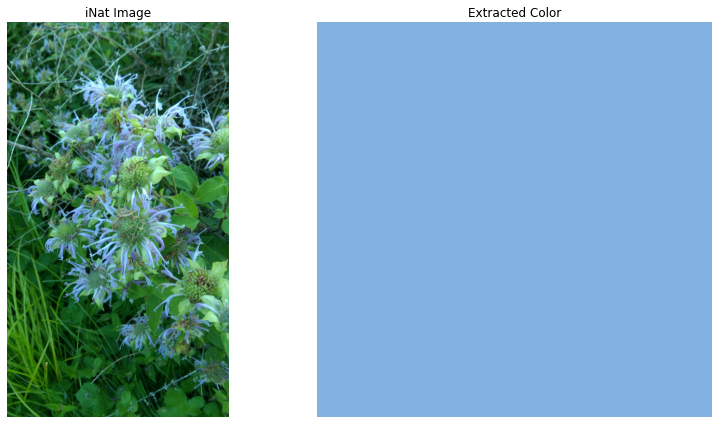

In [12]:
image_idxs = [9093,31606,38896] # high chroma outliers
images = [str(i)+'.jpg' for i in image_idxs]
subdf = color_df[color_df.image_idx.isin(image_idxs)]

for image in images:
    ##############
    # FIRST show segmentation mask from figure 1 notebook
    ##############
    image_path = os.path.join("/Volumes/My Passport/monarda_fistulosa_segmentation/image_dataset/gpt_filtered_images/",image)
    base_name = os.path.basename(image_path)
    base_name_no_ext = os.path.splitext(base_name)[0]
    json_path = os.path.join('/Volumes/My Passport/monarda_fistulosa_segmentation/segmentation_results',f"{base_name_no_ext}.json")

    with open(json_path, "r") as json_file:
        data = json.load(json_file)

    # base64 segmentation mask
    seg_mask_base64 = data['segmentation_mask']

    # decode mask
    mask_data = base64.b64decode(seg_mask_base64)
    mask_image = Image.open(BytesIO(mask_data))
    mask_np = np.array(mask_image)

    # read the image
    orig_img = cv2.imread(image_path)
    orig_img_rgb = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

    # resize mask to match image dims
    mask_resized = cv2.resize(mask_np, (orig_img_rgb.shape[1], orig_img_rgb.shape[0]), interpolation=cv2.INTER_NEAREST)
    

    alpha = 0.7 # transparency
    mask_bool = mask_resized.astype(bool)

    # make a copy to draw on
    overlay = orig_img_rgb.copy()

    # solid mask color
    color = np.array([255, 0, 0], dtype=np.float32)

    # adding transparency
    # for each channel, blend only where mask==1
    for c in range(3):
        # orig channel values
        orig_chan = overlay[..., c].astype(np.float32)
        # blended channel
        # = (1-alpha)*orig + alpha*color[c]
        blended = (1 - alpha) * orig_chan + alpha * color[c]
        # write back only under mask
        orig_chan[mask_bool] = blended[mask_bool]
        overlay[..., c] = orig_chan.astype(np.uint8)

    # now plot/save
    plt.figure(figsize=(10,10))
    plt.imshow(overlay)
    plt.axis('off')
    plt.savefig(f"../figures/figures_current/components/figure_3b_mask_{image}", dpi=300, bbox_inches='tight')
    plt.show()
    
    
    ################
    # Next show extracted color
    ################
    image_path = os.path.join("/Volumes/My Passport/monarda_fistulosa_segmentation/image_dataset/gpt_filtered_images/",image)
    base_name = os.path.basename(image_path)
    image_idx = int(image.split('.')[0])

    # read in iamge
    orig_img = cv2.imread(image_path)
    orig_img_rgb = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    
    # get the rgb from the table
    rgb_str = subdf[subdf.image_idx.eq(image_idx)].rgb.iloc[0]
    # convert to ints
    rgb = rgb_str.strip('()').split(', ')
    rgb = [int(i) for i in rgb]
    
    # make a color patch with the extracted color
    patch_height, patch_width = 5, 5  # block size
    color_patch = np.zeros((patch_height, patch_width, 3), dtype=np.uint8)
    color_patch[:] = rgb

    # side-by-side plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # original image
    axes[0].imshow(orig_img_rgb)
    axes[0].set_title("iNat Image")
    axes[0].axis('off')

    # color patch
    axes[1].imshow(color_patch)
    axes[1].set_title("Extracted Color")
    axes[1].axis('off')

    # plot and write
    plt.tight_layout()
    plt.show()